BUS 450

# PART 1: Read and pre-process data

# Step 1.1: Import library and update file

In [ ]:
import pandas as pd
!pip install langdetect

import re
from tqdm import tqdm
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import nltk
from nltk.corpus import stopwords

# Download the stopwords from NLTK
nltk.download('stopwords')

# Set random seed for reproducibility in language detection
DetectorFactory.seed = 0

C:\Users\Asus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Path to the provided CSV file
file_path = 'Crawl_mix_Vinfast.csv'

# Load the CSV file
df = pd.read_csv(file_path)

#inspect data
def inspect(df):
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Unique Values Count': df.nunique(),
        'Null Values Count': df.isnull().sum()
    })
    return summary

inspect(df)

,Data Type,Unique Values Count,Null Values Count
Unnamed: 0,int64,93322,0
Comment Text,object,87358,15
Author Name,object,64692,136
Like Count,float64,440,0
Reply Count,float64,104,0
Video URL,object,394,0
Replies,object,12666,80258
Query,object,27,0
Video ID,object,394,0
Title,object,393,0


# Step 1.2: Preprocessing data

In [ ]:
import pandas as pd

# Step 1: Rename the column to the correct name
df.rename(
    columns={
        'Published At_x': 'Published At'
    },
    inplace=True
)

# Step 2: Ensure the 'Published At' column is a string
df['Published At'] = df['Published At'].astype(str)

# Step 3: Remove the time part by splitting the string at 'T' and taking the date part
# Handle cases where the string might not contain a 'T'
df['Published At'] = df['Published At'].apply(lambda x: x.split('T')[0] if 'T' in x else x)

# Step 4: Convert the cleaned column to datetime, coercing invalid formats to NaT
df['Published At'] = pd.to_datetime(df['Published At'], errors='coerce')

# Debugging: Print first few rows to confirm the changes
print(df[['Published At']].head())


  Published At
0   2024-11-18
1   2024-11-18
2   2024-11-18
3   2024-11-18
4   2024-11-18


In [ ]:
import pandas as pd
import re
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import nltk
from nltk.corpus import stopwords

# Download the stopwords from NLTK
nltk.download('stopwords')

# Set random seed for reproducibility in language detection
DetectorFactory.seed = 0

# Predefined set of English stopwords from NLTK
default_stop_words = set(stopwords.words('english'))

# Additional stopwords to include
additional_stop_words = ['amp', 'rt', 'via', 'st', 'th', 'nd', 'rd', 'pp', 'one', 'two', 'v', 'e.g.', 'eg', 'us','however',
                        'going', 'things', 'could','james','making','anyone','way','less','high','lot','im','lol',
                         'back','something','look','go','well','say','every','turn','three','seen','worst',
                         'ive','ever','would','dont','looks','many','give','take','sure','made','guys','youre','put',
                         'honest','thanks','said','wont','x','extremely','hope','feel','little','wait','definitely',
                         'theres','full','interesting','thank','needs','start','may','thought','away','think','want',
                         'never','without','donut','lots','real','looking', 'make', 'cant','change','row','already',
                         'got','almost','next','though','parts','maybe','quite','thing','actually','absolute','makes',
                         'build','trying','auto','yet','seems','stop','everything','greate','try','worth','great','also',
                         'years','around','getting','another','doesnt','please','cool','day','buy', 'get', 'much', 'see',
                         'tell', 'built', 'coming', 'end', 'gonna','didnt', 'might','hey','point ','keep','guy',
'guess','inside','talking','must','sounds','ago','especially','come','fast','better','find','know','shit','bit','always',
                         'soon','wow','isnt','heard','done','id','right','since','behind','let','still','even','instead',
                         'ask','thinking','later','least','etc','based','man','theyre','really','since','used','oh','hell',
                         'yall','ill','wouldnt','thats','second','common','anything','saw','people']

# Combine default stopwords with additional stopwords
stop_words = default_stop_words.union(additional_stop_words)

# Define acronyms to keep
acronyms_to_keep = {'un'}

def preprocess_tweet(tweet):
    try:
        # Ensure tweet is a string
        if not isinstance(tweet, str):
            return ''

        # Detect language and only proceed if the language is English
        if detect(tweet) != 'en':
            return ''

        # Convert to lowercase
        tweet = tweet.lower()

        # Remove URLs
        tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)

        # Remove user @ references and '#'
        tweet = re.sub(r'\@\w+|\#', '', tweet)

        # Remove special characters, numbers, and punctuations
        tweet = re.sub(r'\d+', '', tweet)
        tweet = re.sub(r'[^\w\s]', '', tweet)

        # Remove non-ASCII characters
        tweet = re.sub(r'[^\x00-\x7F]+', '', tweet)

        # Remove stopwords, but keep important acronyms
        tweet_tokens = tweet.split()
        filtered_words = [word for word in tweet_tokens if word not in stop_words or word in acronyms_to_keep]

        # Join the filtered words back into a single string
        processed_tweet = ' '.join(filtered_words)

        return processed_tweet
    except LangDetectException:
        return ''

# Path to the provided CSV file
#file_path = '/content/drive/My Drive/BUS_450/Data/Crawl_mix_Vinfast.csv'
file_path='Crawl_mix_Vinfast.csv'
# Load the CSV file
df = pd.read_csv(file_path)

# Preprocess the 'content' column and keep only English tweets
df['processed_content'] = df['Comment Text'].apply(preprocess_tweet)

# Filter out empty processed_content
df = df[df['processed_content'].str.strip() != '']

# Select specific columns to save
selected_columns = ['Author Name', 'Comment Text', 'processed_content', 'Published At', 'Like Count', 'Reply Count', 'Replies', 'Tags', 'Views']
df = df[selected_columns]

# Save the processed DataFrame to a new CSV file
output_file = 'Vinfast_processed_.csv'
df.to_csv(output_file, index=False)

# Print the shape of the final DataFrame and confirmation message
print(f'Final DataFrame shape: {df.shape}')
print(f'Final DataFrame saved to: {output_file}')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Final DataFrame shape: (20714, 9)
Final DataFrame saved to: Vinfast_processed_.csv


In [ ]:
df['Comment Text'] = df['Comment Text'].replace({'vf':'vinfast'}, regex=True)
print(df)

               Author Name  \
0                  @3113jp   
1      @longnguyenngoc-r4h   
2          @motgocnhin5343   
3                 @Trump02   
4            @anthonyc8499   
...                    ...   
92881           @R56Cooper   
92885            @thethutv   
92978          @namlam9226   
93058    @honglongthan9576   
93228       @bennguyen9847   

                                                                                                                                                                                                                                                                                                                                                                                            Comment Text  \
0                                                                                                                                                                                                                                                  

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('Vinfast_processed_.csv')
df.head()

,Author Name,Comment Text,processed_content,Published At,Like Count,Reply Count,Replies,Tags,Views
0,@3113jp,windshields that are 20 sq ft will make insurance premiums crazy high.,windshields sq ft insurance premiums crazy,2024-11-18T13:59:16Z,0.0,0.0,NaN,"vin fsat, vin fast, vinfast vf9, vf8, vinfast vf 9, 2025 vinfast, 2025 EV, best EV, vanfast, venfast, ven fast, fsat ev, fast eve, fast ev, vietnam, made in vietnam, vietnamese, imports, chinese cars, made in china",1219
1,@longnguyenngoc-r4h,"Good car,and you're very cute",good carand cute,2024-11-18T13:59:16Z,0.0,0.0,NaN,"vin fsat, vin fast, vinfast vf9, vf8, vinfast vf 9, 2025 vinfast, 2025 EV, best EV, vanfast, venfast, ven fast, fsat ev, fast eve, fast ev, vietnam, made in vietnam, vietnamese, imports, chinese cars, made in china",1219
2,@motgocnhin5343,"I wish they do away with the big old transmission buttons. They are anything but luxurious. Other than that, VF cars are getting better and better all around.",wish big old transmission buttons luxurious vf cars,2024-11-18T13:59:16Z,0.0,0.0,NaN,"vin fsat, vin fast, vinfast vf9, vf8, vinfast vf 9, 2025 vinfast, 2025 EV, best EV, vanfast, venfast, ven fast, fsat ev, fast eve, fast ev, vietnam, made in vietnam, vietnamese, imports, chinese cars, made in china",1219
3,@Trump02,Stupid design with unacceptable 3rd row,stupid design unacceptable,2024-11-18T13:59:16Z,1.0,0.0,NaN,"vin fsat, vin fast, vinfast vf9, vf8, vinfast vf 9, 2025 vinfast, 2025 EV, best EV, vanfast, venfast, ven fast, fsat ev, fast eve, fast ev, vietnam, made in vietnam, vietnamese, imports, chinese cars, made in china",1219
4,@anthonyc8499,"The VF9 looks like a nice first luxury effort from VinFast. Not sure how well it'll sell unless it's ridiculously priced. That said, the VF9 3rd row shenanigans has to be my favorite scene and i'm glad it didn't get cut.",vf like nice first luxury effort vinfast itll sell unless ridiculously priced vf shenanigans favorite scene glad cut,2024-11-18T13:59:16Z,3.0,0.0,NaN,"vin fsat, vin fast, vinfast vf9, vf8, vinfast vf 9, 2025 vinfast, 2025 EV, best EV, vanfast, venfast, ven fast, fsat ev, fast eve, fast ev, vietnam, made in vietnam, vietnamese, imports, chinese cars, made in china",1219


In [ ]:
#df['Comment Text'] = df['Comment Text'].replace({'la':'Los Angeles', regex=True)
#print(df)

In [ ]:
df.shape

(20714, 9)

# PART 2: Do LDA

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

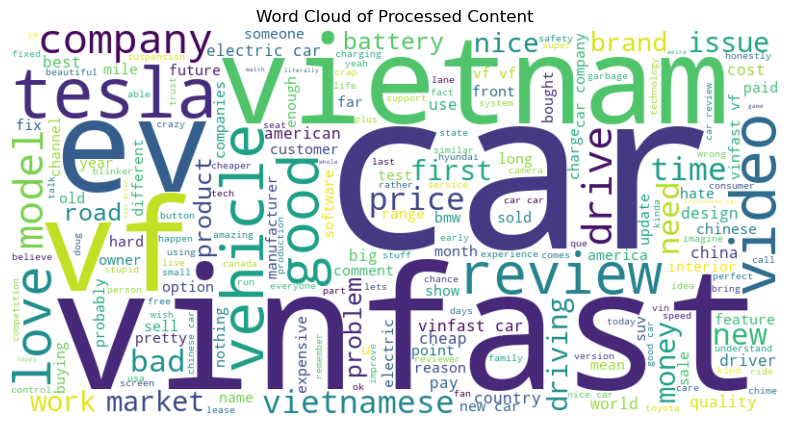

In [ ]:
# Generate the word cloud from the processed content
text = " ".join(review for review in df['processed_content'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Processed Content')
plt.show()

## Finding the Best Number of Topics for LDA (Wait for long time)

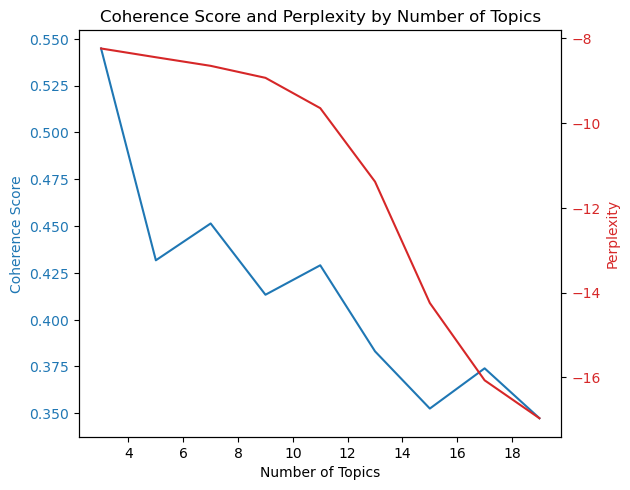

In [ ]:
import numpy as np
import pandas as pd
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random_seed = 100
np.random.seed(random_seed)

# Tokenize the processed content
processed_content = df['processed_content'].apply(lambda x: x.split())

# Create Dictionary
id2word = corpora.Dictionary(processed_content)

# Create Corpus
texts = processed_content

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

def compute_metrics(dictionary, corpus, texts, limit, start=2, step=2):
    coherence_values = []
    perplexity_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=num_topics,
                                       random_state=100,
                                       update_every=2,
                                       chunksize=100,
                                       passes=10,
                                       alpha='auto',
                                       per_word_topics=True)
        model_list.append(model)

        # Coherence
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

        # Perplexity
        perplexity_values.append(model.log_perplexity(corpus))

    return model_list, coherence_values, perplexity_values

# Compute coherence and perplexity values
limit = 20; start = 3; step = 2;
model_list, coherence_values, perplexity_values = compute_metrics(dictionary=id2word, corpus=corpus, texts=texts, start=start, limit=limit, step=step)

# Show graph
x = range(start, limit, step)
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score', color=color)
ax1.plot(x, coherence_values, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Perplexity', color=color)  # we already handled the x-label with ax1
ax2.plot(x, perplexity_values, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Coherence Score and Perplexity by Number of Topics')
plt.show()

## Performing LDA and Visualizing the Results

In [ ]:
import pandas as pd
import gensim
from gensim import corpora
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random_seed = 100


# Tokenize the processed content
processed_content = df['processed_content'].apply(lambda x: x.split())

# Create Dictionary
id2word = corpora.Dictionary(processed_content)

# Create Corpus
texts = processed_content

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# Conduct LDA with the optimal number of topics
optimal_num_topics = 7  # Replace with the number determined from previous analysis
lda_model = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=optimal_num_topics,
                                   random_state=random_seed,
                                   update_every=1,
                                   chunksize=100,
                                   passes=10,
                                   alpha='auto',
                                   per_word_topics=True)

# Output 1: 11 topics with top words (without probabilities)
print("Top 11 topics with words:\n")
topics = lda_model.show_topics(num_topics=optimal_num_topics, num_words=10, formatted=False)
for idx, topic in topics:
    words = [word for word, _ in topic]
    print(f'Topic {idx}: {", ".join(words)}')

# Output 2: Words with their respective values for each topic
print("\nWords with values for each topic:\n")
topic_details = []
for idx in range(optimal_num_topics):
    topic_terms = lda_model.get_topic_terms(idx, topn=10)
    topic_words = [(id2word[word_id], prob) for word_id, prob in topic_terms]
    topic_details.append((idx, topic_words))

for topic_num, topic_words in topic_details:
    print(f'Topic {topic_num}:')
    for word, prob in topic_words:
        print(f'  {word}: {prob:.4f}')
    print()

Top 11 topics with words:

Topic 0: new, lane, country, old, fix, miles, name, safety, tax, perfect
Topic 1: vinfast, vf, cars, vietnam, good, company, review, love, vietnamese, need
Topic 2: america, cost, charging, hood, north, ford, rivian, job, version, call
Topic 3: design, suv, companies, front, priced, driver, problem, assist, batteries, using
Topic 4: car, like, ev, electric, drive, world, road, beautiful, chinese, sell
Topic 5: vehicle, video, nice, market, china, driving, plus, work, issues, product
Topic 6: tesla, price, k, battery, model, bad, subscription, cheap, point, expensive

Words with values for each topic:

Topic 0:
  new: 0.0611
  lane: 0.0273
  country: 0.0229
  old: 0.0222
  fix: 0.0177
  miles: 0.0165
  name: 0.0164
  safety: 0.0123
  tax: 0.0120
  perfect: 0.0111

Topic 1:
  vinfast: 0.0849
  vf: 0.0613
  cars: 0.0419
  vietnam: 0.0336
  good: 0.0287
  company: 0.0216
  review: 0.0194
  love: 0.0168
  vietnamese: 0.0149
  need: 0.0140

Topic 2:
  america: 0.02

In [ ]:
import re
pd.set_option('display.max_colwidth', None)
def find_rows_with_words(dataframe, column, words, condition='and'):
    regex_patterns = [rf'\b{re.escape(word)}\b' for word in words]

    if condition == 'and':
        mask = dataframe[column].apply(lambda text: all(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    elif condition == 'or':
        mask = dataframe[column].apply(lambda text: any(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    else:
        raise ValueError("Condition must be either 'and' or 'or'")

    return dataframe[mask]
                                                    #change the list of word
find=find_rows_with_words(df,'processed_content',['cost'], condition='or') #can change the condition to 'or'
find[['Comment Text','processed_content']].tail(20)

,Comment Text,processed_content
18371,VinFast is building a plant in the USA in North Carolina. This could bring down the cost in the US.,vinfast building plant usa north carolina bring cost
18546,"I don't think the length of time a vehicle has been out should have any say on whether it is allowed to have problems or not. If a company wants to charge 52k for a vehicle, they better bring the heat versus the competition or at the very least throw the same heat as the competitors. Now if the cost was say 10-15k less than competitors on average, that I could get on board with. But I'm not just going to give them a pass because they are new and pay the same price or even higher than competitors that are better.",length time vehicle whether allowed problems company wants charge k vehicle bring heat versus competition throw heat competitors cost k competitors average board pass new pay price higher competitors
18602,"As an American, I prefer to support American companies and American workers. The cherry on top is that Tesla builds the best EVs, by far at a similar cost.",american prefer support american companies american workers cherry top tesla builds best evs far similar cost
18771,"Despite making changes, even after paying $52k for the SUV, the batteries aren't included in the total cost of the vehicle. Unless they've changed it, you have to lease the batteries. It will cost $35 for driving 310 miles per month and $0.11 per mile after that. The alternative is paying $110 per month for unlimited mileage. That's ridiculous!",despite changes paying k suv batteries arent included total cost vehicle unless theyve changed lease batteries cost driving miles per month per mile alternative paying per month unlimited mileage ridiculous
18890,"Sorry, but why would you buy this POS for the same money as the fully loaded Tesia Model Y?!\n This thing should cost no more than $25k to be somewhat appealing.",sorry pos money fully loaded tesia model cost k somewhat appealing
19063,not good for $5200. Its drives like a car that cost $20k.,good drives like car cost k
19257,$53K is insane for this car. Did it cost anything to import?,k insane car cost import
19291,"I always thought Tesla was kind of infamous for not taking into account Customer/Public feedback.\n\nGive this young (?) company credit for the quick response and not being too sensitive to the criticism/feedback.\n\nOverall, it is great to see an entry from Vietnam, and at least aesthetically it looks pretty decent inside and out. \nAt least their cars are just stretched and skewed to fit different model sizes, but at the same time have some brand consistency.\n\nLet’s see how they adjust over the coming years.\n\nHopefully they can figure out the cost to manufacture and retail pricing to better fit their product.",tesla kind infamous taking account customerpublic feedback young company credit quick response sensitive criticismfeedback overall entry vietnam aesthetically pretty decent cars stretched skewed fit different model sizes time brand consistency lets adjust hopefully figure cost manufacture retail pricing fit product
19298,"The price makes this a non-starter. Obviously having to manufacture it in Vietnam and then import it into the US will no doubt come with a lot of added cost, but it seems like an unwise venture. Americans are very normie with their car choices because they simply cannot afford to buy into an oddball car with a high probability of being unreliable. At 50K, most people want some degree of status or clout which Tesla provides, but Vinfast does not, at least not currently.",price nonstarter obviously manufacture vietnam import doubt added cost like unwise venture americans normie car choices simply cannot afford oddball car probability unreliable k degree status clout tesla provides vinfast currently
19460,"I like the idea of the mattress cover you guys hosted in your advertisement. However it's a solid No if I'm required to choose a monthly plan of 15 or 24 doll

In [ ]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
# Save the visualization to an HTML file
pyLDAvis.save_html(vis, 'LDA_Visualization.html')
print('LDA visualization saved to LDA_Visualization.html')
pyLDAvis.display(vis)

LDA visualization saved to LDA_Visualization.html


# Part 4: Sentiment analysis use Varder Lib

In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# Load the dataset
file_path = 'Vinfast_processed_.csv'
df = pd.read_csv(file_path)

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment_score(text):
    sentiment = analyzer.polarity_scores(text)
    return sentiment

# Apply sentiment analysis to the 'processed_content' column
df['sentiment'] = df['processed_content'].apply(get_sentiment_score)

# Extract compound sentiment score and categorize sentiment
df['compound'] = df['sentiment'].apply(lambda x: x['compound'])
df['sentiment_category'] = df['compound'].apply(lambda x: 'positive' if x >= 0.5 else ('negative' if x <= -0.05 else 'neutral'))

# Save the results to a new CSV file
output_file_path = 'FoodSecurity_with_sentiment_vader.csv'
df.to_csv(output_file_path, index=False)

print(f"Sentiment analysis completed. Results saved to {output_file_path}.")

Sentiment analysis completed. Results saved to FoodSecurity_with_sentiment_vader.csv.


## Sentiment Distribution

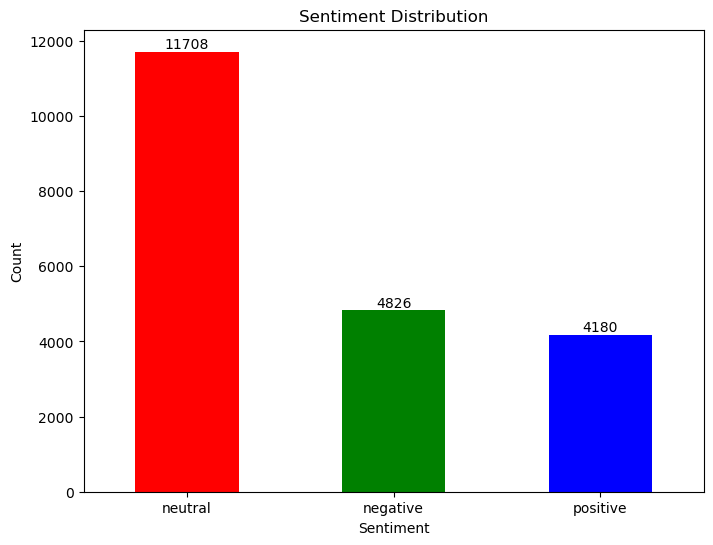

In [ ]:
# Sentiment distribution
sentiment_counts = df['sentiment_category'].value_counts()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=[ 'red', 'green','blue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add counts above the bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

# Positive Comments

In [ ]:
# Tách sentiment positive
df_positive = df[df['sentiment_category'] == 'positive']
df_positive.shape

(4180, 12)

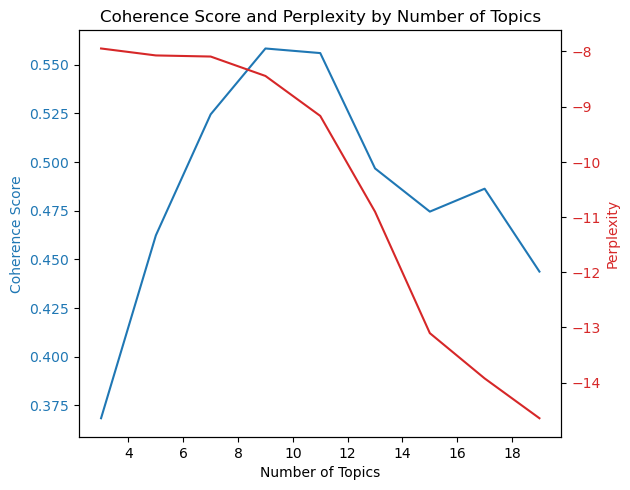

In [ ]:
import numpy as np
import pandas as pd
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random_seed = 100
np.random.seed(random_seed)

# Tokenize the processed content
processed_content = df_positive['processed_content'].apply(lambda x: x.split())

# Create Dictionary
id2word = corpora.Dictionary(processed_content)

# Create Corpus
texts = processed_content

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

def compute_metrics(dictionary, corpus, texts, limit, start=2, step=2):
    coherence_values = []
    perplexity_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=num_topics,
                                       random_state=100,
                                       update_every=2,
                                       chunksize=100,
                                       passes=10,
                                       alpha='auto',
                                       per_word_topics=True)
        model_list.append(model)

        # Coherence
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

        # Perplexity
        perplexity_values.append(model.log_perplexity(corpus))

    return model_list, coherence_values, perplexity_values

# Compute coherence and perplexity values
limit = 20; start = 3; step = 2;
model_list, coherence_values, perplexity_values = compute_metrics(dictionary=id2word, corpus=corpus, texts=texts, start=start, limit=limit, step=step)

# Show graph
x = range(start, limit, step)
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score', color=color)
ax1.plot(x, coherence_values, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Perplexity', color=color)  # we already handled the x-label with ax1
ax2.plot(x, perplexity_values, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Coherence Score and Perplexity by Number of Topics')
plt.show()

In [ ]:
import pandas as pd
import gensim
from gensim import corpora
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random_seed = 100


# Tokenize the processed content
processed_content = df_positive['processed_content'].apply(lambda x: x.split())

# Create Dictionary
id2word = corpora.Dictionary(processed_content)

# Create Corpus
texts = processed_content

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# Conduct LDA with the optimal number of topics
optimal_num_topics = 8  # Replace with the number determined from previous analysis
lda_model = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=optimal_num_topics,
                                   random_state=random_seed,
                                   update_every=1,
                                   chunksize=100,
                                   passes=10,
                                   alpha='auto',
                                   per_word_topics=True)

# Output 1: 9 topics with top words (without probabilities)
print("Top 8 topics with words:\n")
topics = lda_model.show_topics(num_topics=optimal_num_topics, num_words=10, formatted=False)
for idx, topic in topics:
    words = [word for word, _ in topic]
    print(f'Topic {idx}: {", ".join(words)}')

# Output 2: Words with their respective values for each topic
print("\nWords with values for each topic:\n")
topic_details = []
for idx in range(optimal_num_topics):
    topic_terms = lda_model.get_topic_terms(idx, topn=10)
    topic_words = [(id2word[word_id], prob) for word_id, prob in topic_terms]
    topic_details.append((idx, topic_words))

for topic_num, topic_words in topic_details:
    print(f'Topic {topic_num}:')
    for word, prob in topic_words:
        print(f'  {word}: {prob:.4f}')
    print()

Top 8 topics with words:

Topic 0: country, improve, warranty, trust, perfect, technology, screen, customers, super, far
Topic 1: lets, friends, charger, save, nam, watching, art, watched, enjoyed, comment
Topic 2: love, road, free, gorgeous, trip, lori, green, success, check, la
Topic 3: lane, awesome, products, chinese, brands, lanes, appreciate, manufacturers, funny, someone
Topic 4: battery, beautiful, sell, wish, miles, range, pay, charging, plus, america
Topic 5: car, vinfast, like, vf, good, cars, ev, vietnam, price, tesla
Topic 6: amazing, fun, fact, improved, sharing, extra, truly, factory, fair, vin
Topic 7: job, features, driver, name, using, proud, seeing, compared, style, gives

Words with values for each topic:

Topic 0:
  country: 0.0193
  improve: 0.0179
  warranty: 0.0153
  trust: 0.0124
  perfect: 0.0123
  technology: 0.0123
  screen: 0.0114
  customers: 0.0111
  super: 0.0099
  far: 0.0096

Topic 1:
  lets: 0.0162
  friends: 0.0116
  charger: 0.0115
  save: 0.0109
  

In [ ]:
#'someone','la'

In [ ]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
# Save the visualization to an HTML file
pyLDAvis.save_html(vis, 'LDA_Visualization.html')
print('LDA visualization saved to LDA_Visualization.html')
pyLDAvis.display(vis)

LDA visualization saved to LDA_Visualization.html


In [ ]:
import re
pd.set_option('display.max_colwidth', None)
def find_rows_with_words(dataframe, column, words, condition='and'):
    regex_patterns = [rf'\b{re.escape(word)}\b' for word in words]

    if condition == 'and':
        mask = dataframe[column].apply(lambda text: all(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    elif condition == 'or':
        mask = dataframe[column].apply(lambda text: any(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    else:
        raise ValueError("Condition must be either 'and' or 'or'")

    return dataframe[mask]
                                                    #change the list of word
find=find_rows_with_words(df_positive,'processed_content',['la'], condition='or') #can change the condition to 'or'
find[['Comment Text','processed_content']]

,Comment Text,processed_content
1822,"How about taking the time to set the screen up before you make a video---Tesla doesn't give you that flexibility. How much Tesla pay him? I don't drive ""dynamically"" in my Honda Clarity--and I would purchase this vehicle for the price-Apple car play, Hud, and Heated/Ventilated seats ( rear is a bonus)---mostly cushy-ass freeway LA miles for me. Design-wise--Pina Farina designed so wake up Buckethead!",taking time set screen videotesla flexibility tesla pay drive dynamically honda clarityand purchase vehicle priceapple car play hud heatedventilated seats rear bonusmostly cushyass freeway la miles designwisepina farina designed wake buckethead
2036,"I'd love to see you review Hybrids as well and not only fully electric or crème de la crème petrol sport cars 😊\nGreat video, as always!",love review hybrids fully electric crme de la crme petrol sport cars video
4197,"Went to a showroom in LA, and the dude there really couldn't tell me anything about the car other than ""it's an electric SUV made by the Viets."" I guess he got the sense that i knew more than him or something cause i kept asking him questions like where the internals are sourced from, what their dealership stradegy is, etc, but he really didn't seem confident about the product at all, and that kind of told me all i needed to know.",went showroom la dude couldnt car electric suv viets sense knew cause kept asking questions like internals sourced dealership stradegy seem confident product kind told needed
4496,I saw VINFAST here in LA and I want to drive one so bad ! I’m SO ready for this video ! Loving the intro hehe.. yall are incredible and I jumped straight to this video the second I got the Banner Notification ! 🔥🔥🔥,vinfast la drive bad ready video loving intro hehe incredible jumped straight video banner notification
4957,"There was a Vinfast shop at a mall in La Jolla. Just sitting in it, I was impressed. Felt pretty solid and comfy with lots of room. I didn't ask about a test drive, but I wasn't offered one either. For the price it seems like a solid car that just needs to figure things out.",vinfast shop mall la jolla sitting impressed felt pretty solid comfy room test drive wasnt offered either price like solid car figure
8019,I saw idiots buying these at the LA Auto Show last year. I laughed so damn hard and saw this coming. Lmao.,idiots buying la show last year laughed damn hard lmao
8168,"I went to the auto show in LA and on the way in was approach by a woman asking if I'd like to tro sign up to preview a vinfast. I didn't even know she was talking about cars. With a name like that, I honestly thought it was some kind car title or buying service. Wasn't until I saw their booth inside that I realized she had been asking if I wanted to take a riding tour in a car...",went show la approach woman asking like tro sign preview vinfast cars name like honestly kind car title buying service wasnt booth realized asking wanted riding tour car
9367,The Car is just like living in LA ... It's a expensive load of promised hopes and dreams but its just crap all around 🤣,car like living la expensive load promised hopes dreams crap
10726,"It was a beautiful, comfy car!!! Perfect for our little tour of LA ❤️",beautiful comfy car perfect tour la
13533,I used to drive an original Austin Mini in LA and that was 10' overall in length. This looks much taller and probably wider so it looks to be a usable size and would park easily. One of the great advantages on the original Mini. I rather like it.,drive original austin mini la overall length taller probably wider usable size park easily advantages original mini rather like


# Negative

In [ ]:
# Tách sentiment positive
df_negative = df[df['sentiment_category'] == 'negative']
df_negative.shape

(4826, 12)

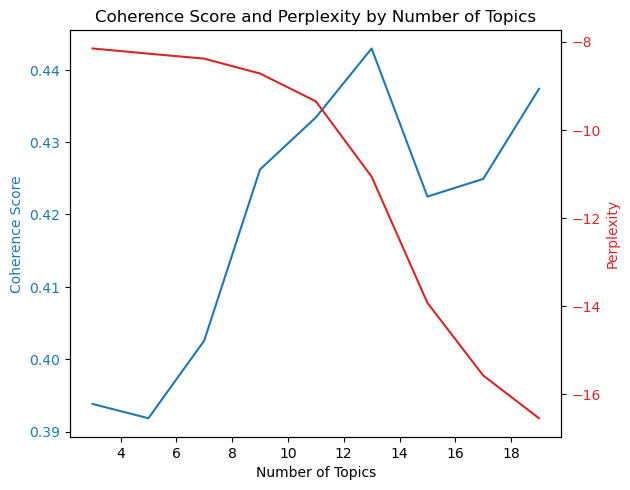

In [ ]:
import numpy as np
import pandas as pd
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random_seed = 100
np.random.seed(random_seed)

# Tokenize the processed content
processed_content = df_negative['processed_content'].apply(lambda x: x.split())

# Create Dictionary
id2word = corpora.Dictionary(processed_content)

# Create Corpus
texts = processed_content

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

def compute_metrics(dictionary, corpus, texts, limit, start=2, step=2):
    coherence_values = []
    perplexity_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=num_topics,
                                       random_state=100,
                                       update_every=2,
                                       chunksize=100,
                                       passes=10,
                                       alpha='auto',
                                       per_word_topics=True)
        model_list.append(model)

        # Coherence
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

        # Perplexity
        perplexity_values.append(model.log_perplexity(corpus))

    return model_list, coherence_values, perplexity_values

# Compute coherence and perplexity values
limit = 20; start = 3; step = 2;
model_list, coherence_values, perplexity_values = compute_metrics(dictionary=id2word, corpus=corpus, texts=texts, start=start, limit=limit, step=step)

# Show graph
x = range(start, limit, step)
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score', color=color)
ax1.plot(x, coherence_values, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Perplexity', color=color)  # we already handled the x-label with ax1
ax2.plot(x, perplexity_values, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Coherence Score and Perplexity by Number of Topics')
plt.show()

In [ ]:
import pandas as pd
import gensim
from gensim import corpora
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random_seed = 100


# Tokenize the processed content
processed_content = df_positive['processed_content'].apply(lambda x: x.split())

# Create Dictionary
id2word = corpora.Dictionary(processed_content)

# Create Corpus
texts = processed_content

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# Conduct LDA with the optimal number of topics
optimal_num_topics = 11  # Replace with the number determined from previous analysis
lda_model = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=optimal_num_topics,
                                   random_state=random_seed,
                                   update_every=1,
                                   chunksize=100,
                                   passes=10,
                                   alpha='auto',
                                   per_word_topics=True)

# Output 1: 11 topics with top words (without probabilities)
print("Top 11 topics with words:\n")
topics = lda_model.show_topics(num_topics=optimal_num_topics, num_words=10, formatted=False)
for idx, topic in topics:
    words = [word for word, _ in topic]
    print(f'Topic {idx}: {", ".join(words)}')

# Output 2: Words with their respective values for each topic
print("\nWords with values for each topic:\n")
topic_details = []
for idx in range(optimal_num_topics):
    topic_terms = lda_model.get_topic_terms(idx, topn=10)
    topic_words = [(id2word[word_id], prob) for word_id, prob in topic_terms]
    topic_details.append((idx, topic_words))

for topic_num, topic_words in topic_details:
    print(f'Topic {topic_num}:')
    for word, prob in topic_words:
        print(f'  {word}: {prob:.4f}')
    print()

Top 11 topics with words:

Topic 0: country, trust, china, products, batteries, american, manufacturers, went, bringing, base
Topic 1: credit, purchase, within, friends, charger, tax, nam, available, watching, owners
Topic 2: seem, blinker, german, unique, totally, expect, copy, takes, hand, dude
Topic 3: lane, super, chinese, adas, compared, lanes, gotta, someone, side, industry
Topic 4: k, range, charging, america, cost, safety, name, trip, fit, prices
Topic 5: car, vinfast, like, vf, good, cars, ev, vietnam, price, tesla
Topic 6: amazing, channel, fun, fact, sharing, extra, paid, starting, logo, touch
Topic 7: beautiful, job, features, glad, nothing, wheel, trendy, everyone, steering, assist
Topic 8: road, wish, technology, center, lets, given, hear, save, surprised, live
Topic 9: gorgeous, content, able, seats, using, affordable, watch, andrea, havent, advanced
Topic 10: love, video, vietnamese, improve, sell, free, perfect, front, customers, color

Words with values for each topic

In [ ]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
# Save the visualization to an HTML file
pyLDAvis.save_html(vis, 'LDA_Visualization.html')
print('LDA visualization saved to LDA_Visualization.html')
pyLDAvis.display(vis)

LDA visualization saved to LDA_Visualization.html


In [ ]:
import re
pd.set_option('display.max_colwidth', None)
def find_rows_with_words(dataframe, column, words, condition='and'):
    regex_patterns = [rf'\b{re.escape(word)}\b' for word in words]

    if condition == 'and':
        mask = dataframe[column].apply(lambda text: all(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    elif condition == 'or':
        mask = dataframe[column].apply(lambda text: any(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    else:
        raise ValueError("Condition must be either 'and' or 'or'")

    return dataframe[mask]
                                                    #change the list of word
find=find_rows_with_words(df_negative,'processed_content',['front'], condition='or') #can change the condition to 'or'
find[['Comment Text','processed_content']]

,Comment Text,processed_content
86,"It's funny that I chose a Vinfast car because in the past 2 years I have witnessed a lot of accidents :)))) I live in Vietnam. At first, I didn't pay much attention to Vinfast cars. In Vietnam, Toyota is number 1. Because Toyota's cars are very durable and rarely break down. However, after about 2 years, when I noticed accidents on the highway and on the streets between Vinfast cars and other brands, I realized it. It seems like other car manufacturers don't make good frames and bodies. They are often crushed and the airbags do not work after a collision. Even if it is just a small collision, the front or body of some car brands will be seriously damaged. But with Vinfast cars, in many accidents I saw that the car frame was still intact, and the people sitting in the car were still very safe. Most recently, the VF8 had an accident on the highway (due to another vehicle accident first). The car was stuck between two trucks, but only the front and back were dented, the body and windows were not broken. I can't post pictures here for everyone to see. Yesterday, the VF9 also had an accident on the highway due to a sudden collision with the two cars in front (the two cars in front collided with each other due to avoiding obstacles). At this time, VF9 is rushing at a speed of 120km/h. The VF9 car weighs nearly 3 tons, meaning the pressure from the collision is huge. The front of the car was completely deformed, but the driver only suffered a broken leg. I can say that compared to what's new, it's superior to other car brands, I don't know. But when it comes to protecting human life, for me Vinfast is currently the star in my heart!",funny chose vinfast car past witnessed accidents live vietnam first pay attention vinfast cars vietnam toyota number toyotas cars durable rarely break noticed accidents highway streets vinfast cars brands realized like car manufacturers good frames bodies often crushed airbags work collision small collision front body car brands seriously damaged vinfast cars accidents car frame intact sitting car safe recently vf accident highway due vehicle accident first car stuck trucks front dented body windows broken post pictures everyone yesterday vf accident highway due sudden collision cars front cars front collided due avoiding obstacles time vf rushing speed kmh vf car weighs nearly tons meaning pressure collision huge front car completely deformed driver suffered broken leg compared whats new superior car brands comes protecting human life vinfast currently star heart
240,"Oh, his review of the VF8's mediocre materials. In Vietnam, there are car accidents related to Vinfast (mostly driver's fault), famous brands such as Toyota, HuynDai, Mercedes, even heavy trucks are ""violently"" abused by Vinfast. onions"" fell all over the cake, dented... =))\r\nI even have a video of a VF8 being hit quite badly by a heavy truck, then the VF8 driver walked out like a god =))\r\nand a video of VF8 crashing a Ford Ranger =))\nIt can be said that Vinfast's chassis and materials have done a very good job of protecting its driver.\r\nI laugh at the notion that the front of the car must be soft to absorb impact. Look at Volvo and see if they are hard or soft?\nI look forward to him evaluating Vinfast after the crash :D\r\nWell, I'm also looking forward to the Vinfast VF9 review video from him, it's an SUV electric E-class",review vfs mediocre materials vietnam car accidents related vinfast mostly drivers fault famous brands toyota huyndai mercedes heavy trucks violently abused vinfast onions fell cake dented video vf hit badly heavy truck vf driver walked like god video vf crashing ford ranger vinfasts chassis materials good job protecting driver laugh notion front car soft absorb impact volvo hard soft forward evaluating vinfast crash forward vinfast vf review video suv electric eclass
1257,The front of that thing is giving me season 1 of breaking bad vibes,front giving season breaking bad 

C:\Users\Asus\AppData\Local\Temp\ipykernel_15452\301408631.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sentiment_over_time = df.groupby([df['Published At'].dt.to_period('M'), 'sentiment_category']).size().unstack().fillna(0)


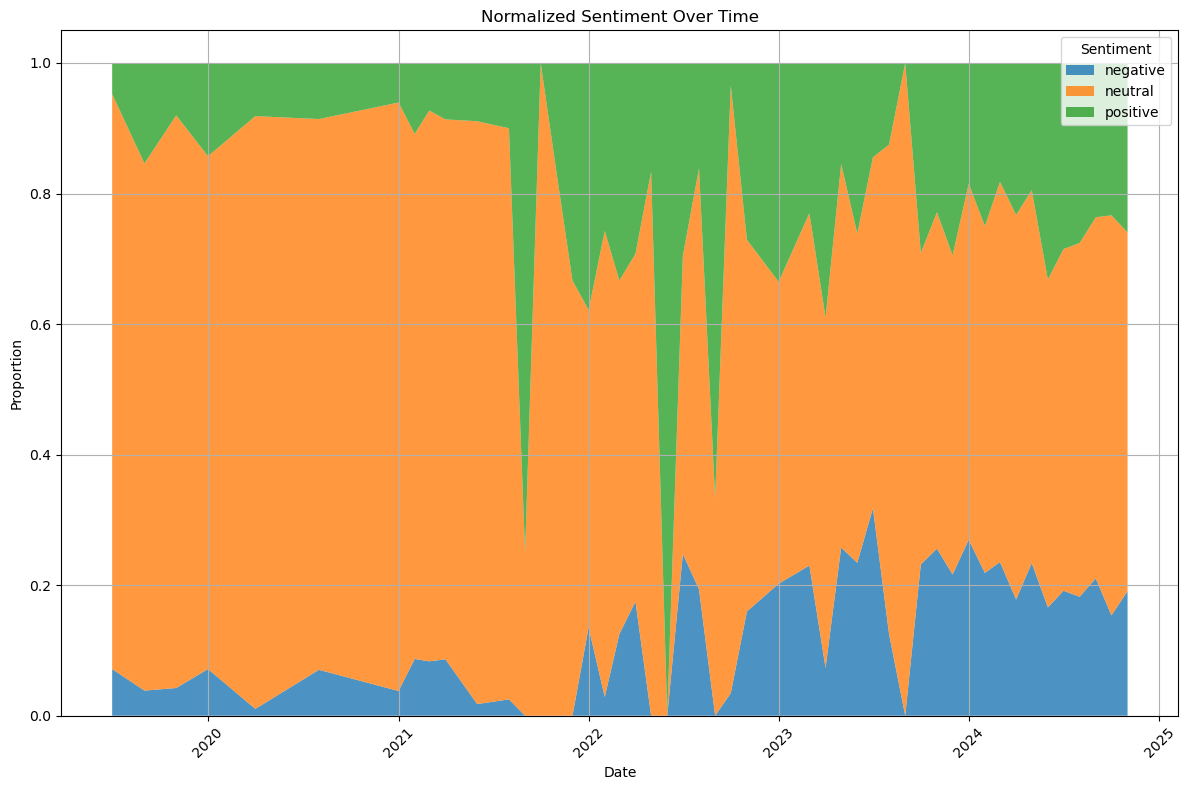

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is your DataFrame and it has 'published_at' and 'sentiment_category' columns
# Convert 'published_at' to datetime
df['Published At'] = pd.to_datetime(df['Published At'])

# Aggregate by month and sentiment category
sentiment_over_time = df.groupby([df['Published At'].dt.to_period('M'), 'sentiment_category']).size().unstack().fillna(0)

# Convert the index to a datetime index for plotting
sentiment_over_time.index = sentiment_over_time.index.to_timestamp()

# Normalize the data
sentiment_normalized = sentiment_over_time.div(sentiment_over_time.sum(axis=1), axis=0)

# Plot normalized sentiment over time as a stacked area chart
plt.figure(figsize=(12, 8))
plt.stackplot(sentiment_over_time.index, sentiment_normalized.T, labels=sentiment_normalized.columns, alpha=0.8)

plt.title('Normalized Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Proportion')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.grid(True)  # Optional: add grid for better readability
plt.tight_layout()  # Optional: adjust layout to fit everything nicely
plt.show()

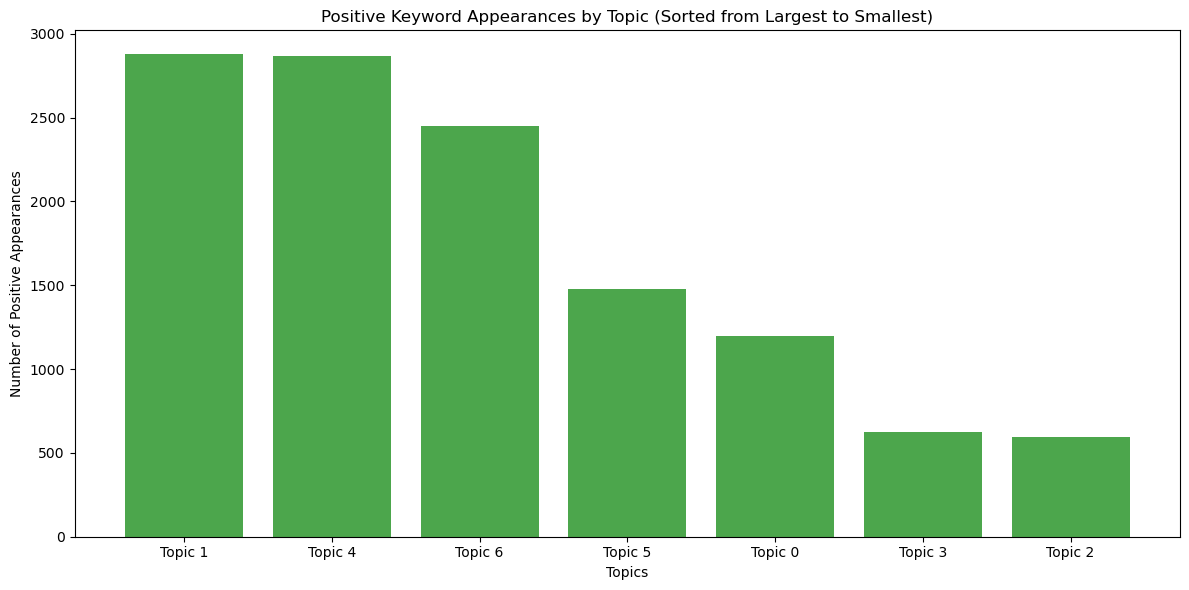

In [ ]:
# Extract topics and their keywords
topics_keywords = {}
for idx in range(optimal_num_topics):
    topic_terms = lda_model.get_topic_terms(idx, topn=10)
    keywords = [id2word[word_id] for word_id, _ in topic_terms]
    topics_keywords[idx] = keywords

# Count positive keyword appearances by topic
positive_counts = {topic: 0 for topic in topics_keywords}
for idx, row in df.iterrows():
    content = row['processed_content']
    sentiment_category = row['sentiment_category']
    if sentiment_category == 'positive':
        for topic, keywords in topics_keywords.items():
            if any(keyword in content for keyword in keywords):
                positive_counts[topic] += 1

# Sort topics by the number of positive appearances
positive_sorted = sorted(positive_counts.items(), key=lambda x: x[1], reverse=True)
sorted_topics_positive = [topic for topic, _ in positive_sorted]
sorted_positive_values = [value for _, value in positive_sorted]

# Plot Positive Keyword Appearances (Sorted)
plt.figure(figsize=(12, 6))
plt.bar(range(len(sorted_topics_positive)), sorted_positive_values, color='green', alpha=0.7)
plt.xlabel("Topics")
plt.ylabel("Number of Positive Appearances")
plt.title("Positive Keyword Appearances by Topic (Sorted from Largest to Smallest)")
plt.xticks(range(len(sorted_topics_positive)), [f"Topic {i}" for i in sorted_topics_positive])
plt.tight_layout()
plt.show()

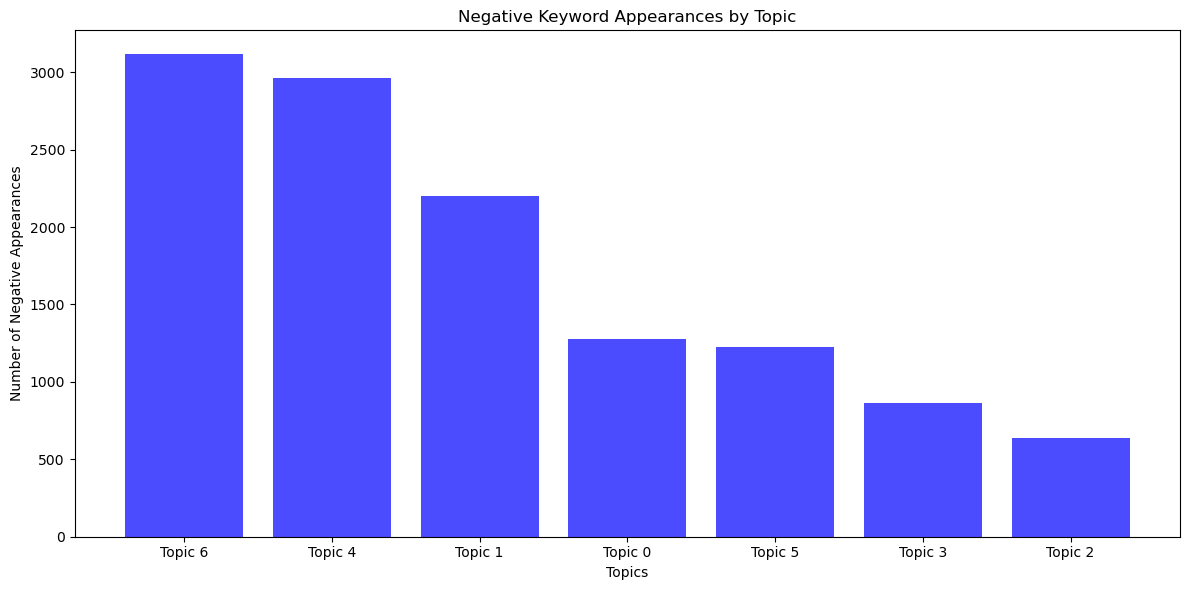

In [ ]:
# Count negative keyword appearances by topic
negative_counts = {topic: 0 for topic in topics_keywords}
for idx, row in df.iterrows():
    content = row['processed_content']
    sentiment_category = row['sentiment_category']
    if sentiment_category == 'negative':
        for topic, keywords in topics_keywords.items():
            if any(keyword in content for keyword in keywords):
                negative_counts[topic] += 1

# Sort topics by the number of negative appearances
negative_sorted = sorted(negative_counts.items(), key=lambda x: x[1], reverse=True)
sorted_topics_negative = [topic for topic, _ in negative_sorted]
sorted_negative_values = [value for _, value in negative_sorted]

# Plot Negative Keyword Appearances (Sorted)
plt.figure(figsize=(12, 6))
plt.bar(range(len(sorted_topics_negative)), sorted_negative_values, color='blue', alpha=0.7)
plt.xlabel("Topics")
plt.ylabel("Number of Negative Appearances")
plt.title("Negative Keyword Appearances by Topic")
plt.xticks(range(len(sorted_topics_negative)), [f"Topic {i}" for i in sorted_topics_negative])
plt.tight_layout()
plt.show()


Topic 0:
  new: 0.0611
  lane: 0.0273
  country: 0.0229
  old: 0.0222
  fix: 0.0177
  miles: 0.0165
  name: 0.0164
  safety: 0.0123
  tax: 0.0120
  perfect: 0.0111

Topic 1:
  vinfast: 0.0849
  vf: 0.0613
  cars: 0.0419
  vietnam: 0.0336
  good: 0.0287
  company: 0.0216
  review: 0.0194
  love: 0.0168
  vietnamese: 0.0149
  need: 0.0140

Topic 2:
  america: 0.0287
  cost: 0.0201
  charging: 0.0177
  hood: 0.0174
  north: 0.0161
  ford: 0.0153
  rivian: 0.0137
  job: 0.0136
  version: 0.0107
  call: 0.0105

Topic 3:
  design: 0.0269
  suv: 0.0238
  companies: 0.0190
  front: 0.0140
  priced: 0.0108
  driver: 0.0107
  problem: 0.0087
  assist: 0.0083
  batteries: 0.0079
  using: 0.0078

Topic 4:
  car: 0.1524 => CAR
  like: 0.0839
  ev: 0.0385
  electric: 0.0192
  drive: 0.0168
  world: 0.0157
  road: 0.0100
  beautiful: 0.0096
  chinese: 0.0094
  sell: 0.0092

Topic 5:
  vehicle: 0.0315
  video: 0.0300
  nice: 0.0286
  market: 0.0214
  china: 0.0180
  driving: 0.0173
  plus: 0.0114
  work: 0.0104
  issues: 0.0102
  product: 0.0096

Topic 6:
  tesla: 0.0543 => TESLA
  price: 0.0533
  k: 0.0516
  battery: 0.0366
  model: 0.0324
  bad: 0.0301
  subscription: 0.0137
  cheap: 0.0137
  point: 0.0122
  expensive: 0.0106

In [ ]:
# Chia làm 3 them
# Interpret ột số từ nổi bật trong theme
# Làm slide
# Tra bài báo , kiếm bài báo về satisfation của xe Vinfast

TOPIC 1: National Pride
=> vinfast, vf, cars, vietnam, good, company, review, love, vietnamese, need

TOPIC 2: america, cost, charging, hood, north, ford, rivian, job, version, call
=>

THEME:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
file_path = '/content/drive/My Drive/BUS450_Vinfast /Data/Crawl_mix_Vinfast.csv'
# Load the CSV file
df2 = pd.read_csv(file_path)

In [9]:
df2.shape

(93322, 23)